# GNN: Message Passing

## Message Passing - Theory

 ## What is Message Passing?

Message passing is the mechanism GNNs use to learn node representations by **aggregating information from neighbourhoods**.

At each layer, every node:
1. **Collects** messages from its neighbours
2. **Aggregates** them (sum / mean / max)
3. **Updates** its own representation

$$h_u^{(k)} = \text{UPDATE}\left(h_u^{(k-1)},\ \text{AGGREGATE}\left(\{h_v^{(k-1)} : v \in \mathcal{N}(u)\}\right)\right)$$

| Symbol | Meaning |
|---|---|
| $h_u^{(k)}$ | embedding of node $u$ after $k$ layers |
| $\mathcal{N}(u)$ | neighbours of $u$ |
| AGGREGATE | collect neighbour info: sum, mean, max |
| UPDATE | combine self + neighbour info: MLP, GRU |

After **k layers**, node $u$ has seen everything within **k hops**.

---

## Why Does It Work? Network Correlation (Homophily)

Message passing only works because of a fundamental property of real-world networks:

> **Connected nodes tend to be similar.**

This is called **homophily** (love of the same). People naturally link with others who share similar characteristics.

### Social Network Analogy

| Dimension | Example |
|---|---|
| Interest | ML researchers cite ML papers |
| Age | teenagers follow teenagers on Instagram |
| Belief | people form echo chambers on social media |
| Location | friends tend to live in the same city |
| Income | similar socioeconomic circles tend to connect |

**Core insight:** your neighbours carry signal about you.

If I know nothing about you, but I know your 5 closest friends are ML engineers in their 30s living in San Francisco — I can make a very good guess about you. That is exactly what message passing formalises.

---

## Homophily Ratio

$$h = \frac{|\{(u,v) \in E : y_u = y_v\}|}{|E|}$$

| $h$ value | Network type | Message passing |
|---|---|---|
| $h \to 1$ | strong homophily | helps a lot |
| $h \approx 0.5$ | random / no structure | neutral or hurts |
| $h \to 0$ | heterophily | hurts — neighbours are opposite class |

**Cora citation graph: $h \approx 0.81$** — papers cite papers in the same research area.  
This is why GNNs work so well on citation graphs.

---

## When Message Passing Fails (Zero Correlation)

If the network has **zero or negative correlation** (heterophily), neighbours carry wrong signal:

| Network | Why it fails |
|---|---|
| Dating graph | edges connect opposite genders by design |
| Predator-prey food web | lion's neighbours = prey (different class) |
| Fraud detection | fraudsters connect to legit nodes to look normal |
| Random graph | no structure → aggregating noise |

**Rule of thumb:** always check homophily ratio during EDA before applying a GNN.  
If $h < 0.5$, consider heterophily-aware architectures (H2GCN, FAGCN) instead.


## Loopy Belief Propagation (LBP)

LBP is a message passing algorithm where nodes pass **probability distributions** (beliefs) to each other along edges until beliefs converge.

---

## Two Potentials to Define

**1. Prior potential** — how likely is label $c$ for node $u$ based on its own features:

$$\psi(y_u = c)$$

**2. Edge potential** — how correlated are labels of $u$ and $v$:

$$\psi(y_u, y_v)$$

| Edge potential | Meaning |
|---|---|
| High $\psi(A, A)$ | neighbours tend to share same label (homophily) |
| High $\psi(A, B)$ | neighbours tend to have opposite labels (heterophily) |

---

## The Message Equation

Message from node $u$ to neighbour $v$ about $v$'s label:

$$m_{u \to v}(y_v) = \sum_{y_u} \psi(y_u) \cdot \psi(y_u, y_v) \cdot \prod_{w \in \mathcal{N}(u) \setminus v} m_{w \to u}(y_u)$$

**Breaking it down:**

| Term | Meaning |
|---|---|
| $\sum_{y_u}$ | sum over all possible labels of $u$ |
| $\psi(y_u)$ | prior belief of $u$ about its own label |
| $\psi(y_u, y_v)$ | how correlated $u$ and $v$'s labels are |
| $\prod_{w \in \mathcal{N}(u) \setminus v} m_{w \to u}(y_u)$ | everything $u$ heard from its other neighbours (excluding $v$) |

Plain English:
> *My message to v about its label = sum over all my possible labels of: (my prior) x (how correlated we are) x (what everyone else told me)*

---

## Algorithm

```
1. Initialise:  m_{u->v}(y_v) = 1  for all edges and labels (uniform)

2. Repeat until convergence:
     for each edge (u, v):
       update m_{u->v} using message equation above

3. Compute final belief at each node u:
     b(y_u) ∝ ψ(y_u) × ∏_{v ∈ N(u)} m_{v->u}(y_u)

4. Assign label:  y_u = argmax b(y_u)
```

---

## Connection to GNN Message Passing

LBP is the **probabilistic ancestor** of GNN message passing:

```
LBP:  m_{u->v} = hand-crafted function of priors + edge potentials
GNN:  m_{u->v} = learned neural network
```

Same propagation structure — GNNs replaced hand-crafted potentials with trainable weights.


## ❇︎ Deep Graph Encoders - Theory ❇︎

## Shallow vs Deep Encoders

So far the embeddings we've discussed (node2vec, DeepWalk, LBP beliefs) are all essentially a **lookup table** — one vector/belief per node, learned directly, with no shared function across nodes.

| | Shallow encoder | Deep encoder (GNN) |
|---|---|---|
| Embedding = | row in a matrix $Z$ | output of a stacked neural network |
| Parameters | $O(\|V\|)$ — one row per node | $O(1)$ per layer — shared weights $W^{(k)}$ |
| New/unseen node? | ❌ no embedding exists | ✅ just run the forward pass |
| New graph entirely? | ❌ impossible | ✅ generalises (inductive) |

**The key unlock:** a deep encoder replaces the lookup table with a function — the same function applied at every node. That's what makes it *deep* (multiple layers of transformation) instead of *shallow* (one flat table).

---

## The Computation Graph Idea

Every node's embedding is defined by **unrolling its neighbourhood into a computation graph**, one layer per hop:

```
Layer 0 (input):     x_A         (raw features)
Layer 1:        h_A picks up neighbours of A
Layer 2:        h_A picks up neighbours-of-neighbours of A
   ...
Layer K:        h_A has seen everything within K hops
```

Two different nodes get **different** computation graphs (because they have different neighbourhoods), but they're all built from the **same shared function** at each layer — this is exactly the parameter sharing that shallow encoders don't have.

---

## The Model

$$h_v^{(0)} = x_v \quad \text{(start from raw node features)}$$

$$h_v^{(k)} = \sigma\left(W^{(k)} \sum_{u \in \mathcal{N}(v)} \frac{h_u^{(k-1)}}{|\mathcal{N}(v)|} \;+\; B^{(k)} h_v^{(k-1)}\right)$$

$$z_v = h_v^{(K)} \quad \text{(final embedding, after K layers)}$$

| Term | Meaning |
|---|---|
| $W^{(k)}$ | transforms **neighbour** messages at layer $k$ |
| $B^{(k)}$ | transforms the node's **own** previous embedding (self-loop / skip term) |
| averaging over $\mathcal{N}(v)$ | keeps the sum order-invariant regardless of neighbour count |
| $\sigma$ | non-linearity (ReLU, etc.) |

Note $W^{(k)}$ and $B^{(k)}$ are **the same for every node** at layer $k$ — this is the parameter sharing that makes the model *inductive*.

---

## Two Design Choices Every GNN Layer Must Make

1. **Aggregation function** — how to combine a variable-size, unordered set of neighbour messages into one fixed-size vector. Must be **permutation invariant** (sum / mean / max — never something order-dependent like concatenation of raw neighbour list).
2. **Self vs neighbour combination** — how much weight to give the node's own previous state vs. what it hears from neighbours (separate weight matrices $W$, $B$ above; other layers use concatenation instead).

Different answers to these two questions is basically what distinguishes GCN, GraphSAGE, and GAT (covered next).

---

## Training a Deep Encoder

- **Supervised**: plug $z_v$ into a task loss directly — e.g. cross-entropy for node classification, using known labels.
- **Unsupervised**: no labels available, so define a loss from the graph structure itself — e.g. push $z_u, z_v$ close together if $u,v$ co-occur on random walks (same idea as node2vec/DeepWalk, but now the embeddings come from a shared encoder function, not a lookup table).

Either way, gradients flow back through $W^{(k)}, B^{(k)}$ at every layer — the layers are trained jointly.

---

## Why This Generalises (the big payoff)

Because $W^{(k)}$ and $B^{(k)}$ don't depend on which node you're looking at:

- A node that **didn't exist during training** can still be embedded — just run its neighbourhood through the same layers.
- A GNN trained on **one graph** can be applied to a **completely different graph** with the same feature schema.

This is the inductive capability shallow encoders fundamentally cannot have — node2vec has to be retrained from scratch if the graph changes at all, because every embedding is its own free parameter.
</cell id="40209028">

## The Precise GCN Formula (Kipf & Welling, 2017)

The equation in the Model section above is a simplified, GraphSAGE-flavoured stand-in for intuition. The actual, original GCN layer-wise propagation rule is:

$$H^{(l+1)} = \sigma\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}\, H^{(l)}\, W^{(l)}\right)$$

| Symbol | Meaning |
|---|---|
| $A$ | raw adjacency matrix of the graph ($N \times N$) |
| $\hat{A} = A + I_N$ | adjacency **with self-loops added** — lets a node include itself in its own aggregation |
| $\hat{D}$ | diagonal degree matrix of $\hat{A}$: $\hat{D}_{ii} = \sum_j \hat{A}_{ij}$ (degree **including** the self-loop) |
| $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$ | the **symmetrically normalized adjacency** — does "aggregate neighbours" and "normalize by degree" in a single matrix multiply |
| $H^{(l)} \in \mathbb{R}^{N \times F_l}$ | every node's layer-$l$ embedding, stacked as rows ($H^{(0)} = X$, raw input features) |
| $W^{(l)} \in \mathbb{R}^{F_l \times F_{l+1}}$ | the one trainable weight matrix for this layer |

**Per-node, this expands to:**

$$h_i^{(l+1)} = \sigma\left(\sum_{j \in \mathcal{N}(i)\cup\{i\}} \frac{1}{\sqrt{\hat d_i\,\hat d_j}}\, h_j^{(l)}\, W^{(l)}\right)$$

**Two differences from the earlier simplified equation:**

1. **No separate $B$ matrix.** The self-term isn't a second branch here — it's folded directly into the sum by adding a self-loop to $\hat A$ before normalizing. Node $i$ becomes one of its own "neighbours" ($j=i$ is one term in the sum), so a single $W$ handles both self and neighbour information together.
2. **Normalization is $\frac{1}{\sqrt{\hat d_i \hat d_j}}$, not a plain mean $\frac{1}{|\mathcal{N}(v)|}$.** This symmetric normalization down-weights an edge more if *either* endpoint has high degree — a low-degree node's message to a high-degree hub is scaled differently than a high-degree node's message to another high-degree node. This is Kipf & Welling's specific design choice to keep the propagation numerically stable across many stacked layers.

## GraphSAGE Equation (Hamilton, Ying, Leskovec, 2017)

GraphSAGE takes a different structural approach from both the simplified equation and the precise GCN formula above: instead of adding or normalized-summing self and neighbour terms, it **concatenates** them, and treats the aggregator itself as a swappable component. A 3-step recipe per node $v$, per layer $k$:

**Step 1 — Aggregate neighbours:**
$$h_{\mathcal{N}(v)}^{(k)} = \text{AGGREGATE}_k\big(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\big)$$

**Step 2 — Concatenate self with the aggregated neighbours, then transform:**
$$h_v^{(k)} = \sigma\Big(W^{(k)} \cdot \text{CONCAT}\big(h_v^{(k-1)},\ h_{\mathcal{N}(v)}^{(k)}\big)\Big)$$

**Step 3 — L2-normalize the result:**
$$h_v^{(k)} = \dfrac{h_v^{(k)}}{\|h_v^{(k)}\|_2}$$

---

**Common choices for $\text{AGGREGATE}_k$** — this pluggable aggregator is GraphSAGE's central contribution, not one fixed formula:

| Aggregator | Formula |
|---|---|
| **Mean** | $h_{\mathcal{N}(v)}^{(k)} = \text{mean}\big(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\big)$ |
| **Pool** | $h_{\mathcal{N}(v)}^{(k)} = \max\big(\{\sigma(W_{\text{pool}} h_u^{(k-1)} + b) : u \in \mathcal{N}(v)\}\big)$ — each neighbour passes through its own small MLP first, *then* elementwise max is taken |
| **LSTM** | run an LSTM over the neighbours in a random order (GraphSAGE re-randomizes the order every training step, since LSTMs aren't naturally permutation-invariant) |

---

**What's actually different from the equations already covered:**

1. **Concatenation, not addition.** The earlier simplified equation added two separately-weighted branches ($W^{(k)}\text{AGG}(\ldots) + B^{(k)}h_v^{(k-1)}$); the precise GCN formula folds self in as *one more neighbour* inside a single normalized sum. GraphSAGE instead **concatenates** the self vector and the aggregated-neighbour vector side by side, then applies a single $W^{(k)}$ to the whole concatenation — letting the model weigh "my own state" and "what my neighbours say" completely independently, since they occupy separate slices of the input.
2. **L2 normalization every layer** — neither of the earlier two equations does this. It keeps embedding magnitudes from drifting or exploding across many stacked layers.
3. **Pluggable aggregator.** GCN and the simplified equation both commit to one fixed rule (mean or normalized-sum); GraphSAGE treats $\text{AGGREGATE}_k$ as swappable — mean/pool/LSTM are all valid plug-ins into the same 3-step skeleton.

**One more contribution worth knowing (a training-procedure detail, not part of the equation itself):** GraphSAGE samples a **fixed-size subset** of each node's neighbours rather than using all of them. This is what makes it scale to graphs too large for full-batch training — unlike every equation covered so far, which assumed using *every* neighbour.

## Seeing It: A Graph vs. Its Computation Graph

Let's make "unrolling the neighbourhood" concrete. We'll reuse the same 4-node cycle (A–B–C–D–A) from the LBP music-taste example, and unroll node **A**'s computation graph for **2 layers**.

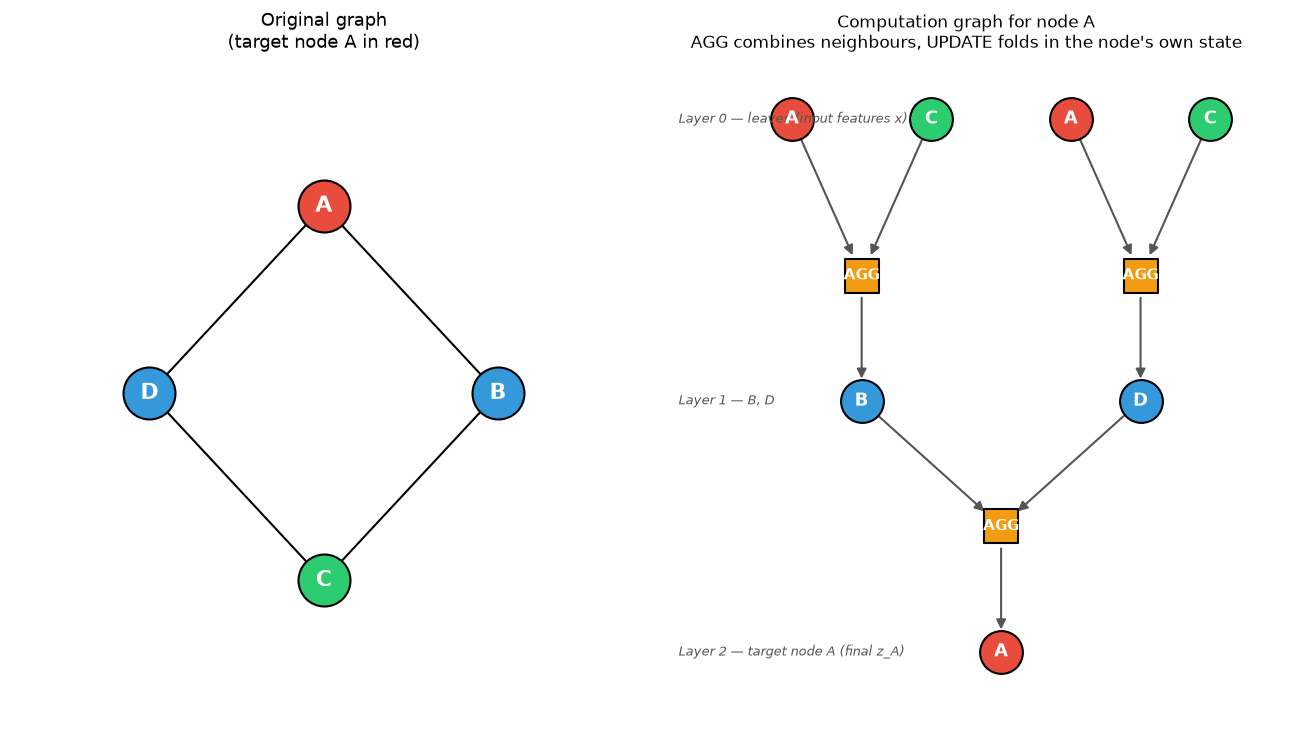

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))

# ---------------- Left: the original graph ----------------
ax = axes[0]
pos = {'A': (0, 1), 'B': (1, 0), 'C': (0, -1), 'D': (-1, 0)}
edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')]

for u, v in edges:
    x1, y1 = pos[u]; x2, y2 = pos[v]
    ax.plot([x1, x2], [y1, y2], 'k-', lw=1.5, zorder=1)

node_color = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71', 'D': '#3498db'}
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1400, color=node_color[node], zorder=2, edgecolors='black', linewidths=1.5)
    ax.text(x, y, node, ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=3)

ax.set_title("Original graph\n(target node A in red)", fontsize=13)
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
ax.axis('off')

# ---------------- Right: A's computation graph, Layer 0 at the TOP ----------------
ax = axes[1]

# key: (x, y, label, color, shape)  shape: 'o' node embedding, 's' AGG box
nodes = {
    'A1':   (-2.4, 3.0, 'A',   '#e74c3c', 'o'),
    'C1':   (-0.8, 3.0, 'C',   '#2ecc71', 'o'),
    'A2':   (0.8,  3.0, 'A',   '#e74c3c', 'o'),
    'C2':   (2.4,  3.0, 'C',   '#2ecc71', 'o'),
    'AGGB': (-1.6, 2.0, 'AGG', '#f39c12', 's'),
    'AGGD': (1.6,  2.0, 'AGG', '#f39c12', 's'),
    'B':    (-1.6, 1.2, 'B',   '#3498db', 'o'),
    'D':    (1.6,  1.2, 'D',   '#3498db', 'o'),
    'AGGA': (0.0,  0.4, 'AGG', '#f39c12', 's'),
    'A':    (0.0, -0.4, 'A',   '#e74c3c', 'o'),
}

edges_down = [('A1', 'AGGB'), ('C1', 'AGGB'), ('AGGB', 'B'),
              ('A2', 'AGGD'), ('C2', 'AGGD'), ('AGGD', 'D'),
              ('B', 'AGGA'), ('D', 'AGGA'), ('AGGA', 'A')]

for u, v in edges_down:
    x1, y1, *_ = nodes[u]; x2, y2, *_ = nodes[v]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5,
                                 shrinkA=16, shrinkB=16, mutation_scale=14))

for key, (x, y, label, color, shape) in nodes.items():
    size = 600 if shape == 's' else 950
    ax.scatter(x, y, s=size, color=color, marker=shape, zorder=3, edgecolors='black', linewidths=1.5)
    ax.text(x, y, label, ha='center', va='center',
             fontsize=10.5 if shape == 's' else 13, fontweight='bold', color='white', zorder=4)

for y, text in [(3.0, 'Layer 0 — leaves (input features x)'),
                 (1.2, 'Layer 1 — B, D'),
                 (-0.4, 'Layer 2 — target node A (final z_A)')]:
    ax.text(-3.7, y, text, ha='left', va='center', fontsize=9.5, style='italic', color='#555')

ax.set_title("Computation graph for node A\nAGG combines neighbours, UPDATE folds in the node's own state", fontsize=12)
ax.set_xlim(-4.0, 3.2); ax.set_ylim(-0.9, 3.4)
ax.axis('off')

plt.tight_layout()
plt.show()

**What to notice:**

- Layer 0 (top) is the leaves — raw input features $x$. Layer 1 (middle) is A's direct neighbours, B and D. Layer 2 (bottom) is A itself — the target node, whose final embedding $z_A$ is the output.
- The **orange AGG boxes** are a separate, visible step: neighbour embeddings flow into AGG first (combined via sum/mean/max), and only *then* does UPDATE combine that aggregated result with the node's own previous state to produce the new embedding. This is exactly $h_v^{(k)} = \text{UPDATE}\big(h_v^{(k-1)},\ \text{AGG}(\{h_u^{(k-1)}\})\big)$ — AGG and UPDATE are two distinct operations, not one fused step. (The node's own previous state — the "self" term, $B^{(k)}h_v^{(k-1)}$ — feeds into UPDATE too, just not drawn here to keep the diagram clean.)
- **C appears twice at Layer 0** — once reached via B, once via D. That's not a mistake: it's the direct consequence of the cycle in the original graph. Every extra layer you add, more of these repeated visits show up, and information starts getting counted more than once.

This is the *same* phenomenon as the double-counting you saw in Loopy Belief Propagation — except here it doesn't break correctness (a GNN layer is just a fixed, well-defined function, not an approximate inference algorithm). Instead it shows up as **over-smoothing**: stack too many GNN layers, and every node's computation graph starts overlapping so much that all node embeddings converge toward the same average.

## Where Does the Non-linearity (ReLU) Fit In?

Looking back at the computation graph: the **orange AGG box** and the **circle** do very different jobs, and only one of them touches the non-linearity.

$$h_v^{(k)} = \sigma\left(W^{(k)} \cdot \text{AGG}(\{h_u^{(k-1)}\}) \;+\; B^{(k)} \cdot h_v^{(k-1)}\right)$$

| Diagram element | What happens | Non-linearity? |
|---|---|---|
| AGG box (orange) | sum / mean / max of neighbour embeddings — a plain, linear combination | No |
| Circle (B, D, A) | $W^{(k)}\cdot(\text{AGG output}) + B^{(k)}\cdot(\text{self})$, then **ReLU** applied once, all in one shot | Yes |

**Why this matters:** AGG is deliberately kept simple and linear (sum/mean/max) so it stays permutation-invariant — a node's neighbours have no order, and adding weights or a nonlinearity that depended on position inside AGG would break that. All the actual "thinking" — the learned weight matrices *and* the non-linearity that gives the model its expressive power — happens once per node, at UPDATE, right after aggregation is already done.

*Caveat:* this holds for the GCN-style layer above. In the more general MPNN framework, the message function (computed before aggregation) can also be a small neural net with its own non-linearity — but for everything in this notebook so far, ReLU fires exactly once per node per layer, at the moment the new embedding (the circle) is produced.

## Why $W^{(k)}$ Multiplies $h^{(k-1)}$ (not a mismatch — this is how every layered net works)

A common point of confusion: the equation has $W^{(k)}$ (current layer's weights) multiplying $h^{(k-1)}$ (*previous* layer's activations). It looks like we're "reusing an old layer's weights," but this is exactly how a plain DNN works too — nothing GNN-specific about it.

**Plain DNN, layer $l$:**
$$a^{(l)} = \sigma\big(W^{(l)} \cdot a^{(l-1)} + b^{(l)}\big)$$

**GNN, layer $k$:**
$$h_v^{(k)} = \sigma\Big(W^{(k)} \cdot \text{AGG}(h_u^{(k-1)}) + B^{(k)} \cdot h_v^{(k-1)}\Big)$$

Same pattern in both: $W^{(l)}$ / $W^{(k)}$ is a **brand-new weight matrix that belongs only to this layer** — it has never been used before. It just happens to be applied to the *previous* layer's output, because that previous output **is** this layer's input. There's no other data available to feed into layer $k$ except whatever layer $k-1$ produced.

**The rule to remember:**
- The **weight's index** = which layer is currently being computed (the transformation happening *now*).
- The **activation's index** = one step behind, because it's the input being fed *into* that transformation.

If $W^{(k)}$ instead multiplied $h^{(k)}$, that would mean layer $k$ needs its own output before it's been computed — a contradiction. So $W^{(k)}$ acting on $h^{(k-1)}$ isn't an inconsistency to untangle; it's the only way a feed-forward layer can be defined, GNN or not.

### Same Equation, $l \to l{+}1$ Notation

Some papers/textbooks (e.g. GraphSAGE) write the layer index as $l \to l+1$ instead of $k-1 \to k$. It's the identical equation, just relabeled:

$$h_v^{(l+1)} = \sigma\Big(W^{(l+1)} \cdot \text{AGG}\big(\{h_u^{(l)} : u \in \mathcal{N}(v)\}\big) \;+\; B^{(l+1)} \cdot h_v^{(l)}\Big)$$

"Layer $l+1$'s embedding = current layer's weights ($W^{(l+1)}, B^{(l+1)}$) applied to layer $l$'s embeddings (neighbours via AGG, self directly)." Same rule as before: weight index = layer being computed, activation index = one step behind.

## Wait — Where Does the Self-Term's Value Actually Come From?

Good catch to sit with: in A's computation graph, we only ever drew the **neighbour** pathway (leaves → AGG → B/D → AGG → A). The self-term ($B^{(k)} h_v^{(k-1)}$) was just labelled, never actually traced. So where does it come from?

**It depends on which layer you're at:**

- **B and D's self-term (needed at layer 0 → 1)** is just $x_B$ and $x_D$ — the raw input feature. Free. No computation needed, because layer 0 *is* the raw data.
- **A's self-term (needed at layer 1 → 2, to produce $z_A$)** is $h_A^{(1)}$ — **not** $x_A$! This is a layer-1 quantity, and layer-1 quantities are never free. It has to be computed the exact same way $h_B^{(1)}$ and $h_D^{(1)}$ were: by aggregating **A's own neighbours** (B and D) at layer 0:

$$h_A^{(1)} = \sigma\big(W^{(1)} \cdot \text{AGG}(x_B, x_D) + B^{(1)} \cdot x_A\big)$$

So the diagram is technically missing a branch — a small AGG box combining $x_B, x_D$ to produce A's own $h_A^{(1)}$, drawn in parallel with the B/D subtrees, not through them.

**Why this doesn't actually break anything:** a real GNN never computes one node's tree in isolation. It computes **one whole layer for every node in the graph at the same time**:

$$H^{(l+1)} = \sigma\big(\hat{A} \cdot H^{(l)} \cdot W^{(l+1)} + H^{(l)} \cdot B^{(l+1)}\big)$$

($\hat A$ = graph's adjacency, $H^{(l)}$ = every node's layer-$l$ embedding, stacked together.) In one synchronized pass, $h_B^{(1)}$, $h_D^{(1)}$, **and** $h_A^{(1)}$ all get produced together. So by the time layer 2 runs, A's self-term is already sitting there — computed alongside B and D's, not fetched through some separate tree.

**Takeaway:** only the Layer-0 self-term is a free lookup (raw features). Every self-term above Layer 0 is itself the output of an AGG+UPDATE step — it's just computed for the *whole graph at once*, not traced per-target-node the way our tree diagram does.

## Seeing "One Layer, Whole Graph at Once" With Numbers

Let's actually compute a layer for **all four nodes together**, using the same cycle graph (A–B–C–D–A) and Rock/Jazz feature vectors from before. One matrix multiply will do AGG for every node simultaneously — no per-node tree needed.

In [1]:
import numpy as np

node_names = ['A', 'B', 'C', 'D']

# adjacency matrix for the cycle A-B-C-D-A (order: A, B, C, D)
A_adj = np.array([
    [0, 1, 0, 1],   # A's neighbours: B, D
    [1, 0, 1, 0],   # B's neighbours: A, C
    [0, 1, 0, 1],   # C's neighbours: B, D
    [1, 0, 1, 0],   # D's neighbours: A, C
])

# H^(0): every node's raw feature (Rock, Jazz) -- same values as the LBP example
H0 = np.array([
    [0.9, 0.1],   # A: rock fan
    [0.5, 0.5],   # B: undecided
    [0.1, 0.9],   # C: jazz fan
    [0.5, 0.5],   # D: undecided
])

# toy weights (in a real model these are learned; kept simple here to see the arithmetic)
W1 = np.eye(2) * 0.6   # scales the neighbour (AGG) signal
B1 = np.eye(2) * 0.4   # scales the self signal

def gnn_layer(H, A_adj, W, B):
    print(f"\n--- GNN layer ---\nH = {H}\nA_adj = {A_adj}\nW = {W}\nB = {B}")
    AGG = A_adj @ H             # <-- ONE matmul does AGG for every node at once
    return np.maximum(0, AGG @ W + H @ B), AGG   # ReLU(W . AGG + B . self)

print("Layer 0 -> 1")
H1, AGG0 = gnn_layer(H0, A_adj, W1, B1)
for name, agg, h in zip(node_names, AGG0, H1):
    print(f"  AGG({name}) = {agg}   ->   h_{name}^(1) = {h}")

print("\nLayer 1 -> 2")
H2, AGG1 = gnn_layer(H1, A_adj, W1, B1)  # reuse same toy weights for simplicity
for name, agg, h in zip(node_names, AGG1, H2):
    print(f"  AGG({name}) = {agg}   ->   h_{name}^(2) = {h}")

print(f"\nz_A = h_A^(2) = {H2[0]}  <- just row 'A' of the same matrix everyone else's embedding came from")

Layer 0 -> 1

--- GNN layer ---
H = [[0.9 0.1]
 [0.5 0.5]
 [0.1 0.9]
 [0.5 0.5]]
A_adj = [[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]
W = [[0.6 0. ]
 [0.  0.6]]
B = [[0.4 0. ]
 [0.  0.4]]
  AGG(A) = [1. 1.]   ->   h_A^(1) = [0.96 0.64]
  AGG(B) = [1. 1.]   ->   h_B^(1) = [0.8 0.8]
  AGG(C) = [1. 1.]   ->   h_C^(1) = [0.64 0.96]
  AGG(D) = [1. 1.]   ->   h_D^(1) = [0.8 0.8]

Layer 1 -> 2

--- GNN layer ---
H = [[0.96 0.64]
 [0.8  0.8 ]
 [0.64 0.96]
 [0.8  0.8 ]]
A_adj = [[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]
W = [[0.6 0. ]
 [0.  0.6]]
B = [[0.4 0. ]
 [0.  0.4]]
  AGG(A) = [1.6 1.6]   ->   h_A^(2) = [1.344 1.216]
  AGG(B) = [1.6 1.6]   ->   h_B^(2) = [1.28 1.28]
  AGG(C) = [1.6 1.6]   ->   h_C^(2) = [1.216 1.344]
  AGG(D) = [1.6 1.6]   ->   h_D^(2) = [1.28 1.28]

z_A = h_A^(2) = [1.344 1.216]  <- just row 'A' of the same matrix everyone else's embedding came from


**What just happened:**

- `A_adj @ H` computed `AGG(neighbours)` for **all four nodes in one line** — no loop, no per-node tree. Notice `AGG(A)` and `AGG(C)` came out identical (`[1, 1]`) in layer 0→1: A and C both connect to {B, D}, so they aggregate the same neighbours. Same for B and D (both connect to {A, C}).
- `h_A^{(1)}` was produced in the **exact same call** that produced `h_B^{(1)}`, `h_C^{(1)}`, `h_D^{(1)}`. This directly answers the earlier question — A's self-term for the next layer isn't fetched from some separate tree, it's already sitting in row A of `H1`, computed alongside everyone else.
- `z_A = h_A^{(2)}` is just row A of the final matrix `H2` — the whole "computation graph" we drew earlier is really just a way of tracing *which raw inputs* end up influencing that one row, not how the engine actually computes it.
- Bonus: notice the numbers are already drifting closer together after just 2 layers (`h_A^{(2)} = [1.34, 1.22]` vs `h_C^{(2)} = [1.22, 1.34]` — much closer than `x_A=[0.9,0.1]` vs `x_C=[0.1,0.9]`). That's the over-smoothing effect from earlier, now visible in real numbers.

## Stacking Layers: Why K Layers = K-Hop Receptive Field

**The rule:** a single GNN layer only ever touches **direct (1-hop) neighbours**. It never reaches further than that in one step — you saw this above: $h_A^{(1)}$ only uses $x_B, x_D$, never $x_C$ directly.

So how does stacking layers let a node "see" further? Not by any one layer looking further — by **composing** layers, where each layer's neighbours already carry a summary of *their own* neighbours from the round before:

- **$h_A^{(0)} = x_A$** — sees only itself (0 hops).
- **$h_A^{(1)} = \sigma(W^{(1)}\text{AGG}(x_B, x_D) + B^{(1)}x_A)$** — directly touches B, D only (1 hop). C is not involved yet.
- **$h_A^{(2)} = \sigma(W^{(2)}\text{AGG}(h_B^{(1)}, h_D^{(1)}) + B^{(2)}h_A^{(1)})$** — still only directly touches B, D. But $h_B^{(1)}$ and $h_D^{(1)}$ **already have C baked into them** (from their own layer-1 update, which aggregated *their* neighbours — and C is a neighbour of both B and D). So A absorbs a trace of C *indirectly*, through B and D, without ever "looking at" C itself.

**General rule:** after $K$ layers, node $v$'s embedding has indirectly incorporated every node within $K$ hops — its **receptive field** is exactly the $K$-hop neighbourhood. This is why "number of layers" is a real hyperparameter: too few layers and a node never hears from distant-but-relevant parts of the graph; too many layers and (as we saw earlier) the receptive fields of *all* nodes start overlapping so much that everyone's embedding converges — over-smoothing.

Let's see the receptive field actually grow on our 4-node cycle.

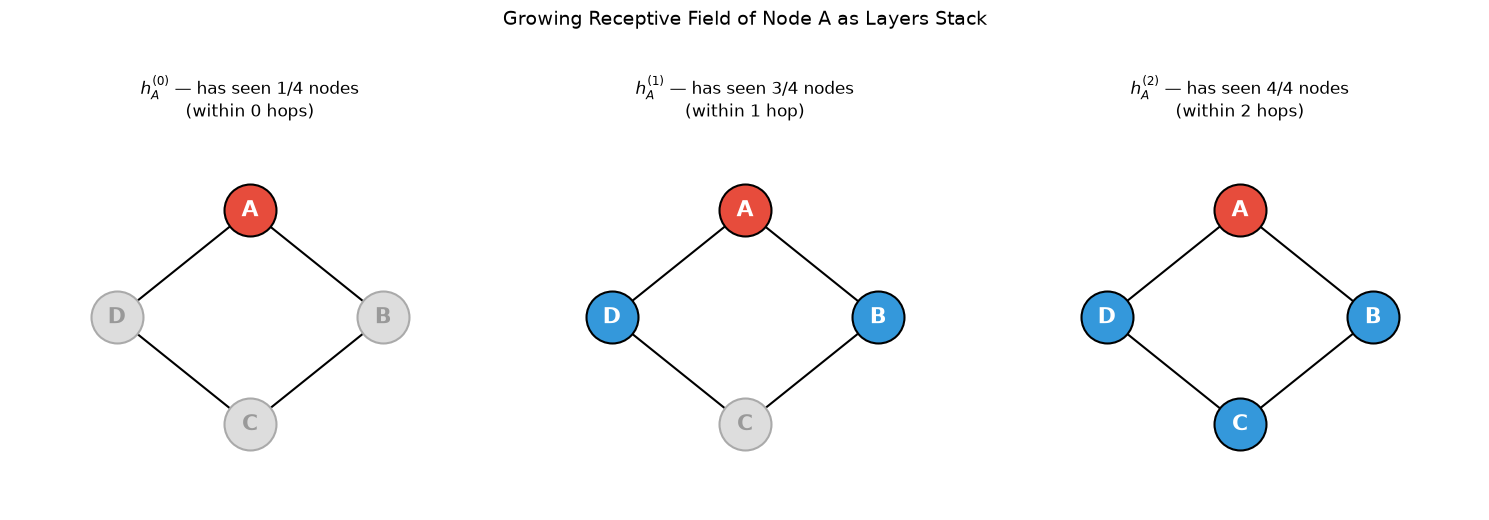

In [2]:
import matplotlib.pyplot as plt

pos = {'A': (0, 1), 'B': (1, 0), 'C': (0, -1), 'D': (-1, 0)}
edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')]

# true hop-distance of every node from A on this cycle graph
hop_distance = {'A': 0, 'B': 1, 'D': 1, 'C': 2}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for k, ax in zip([0, 1, 2], axes):
    for u, v in edges:
        x1, y1 = pos[u]; x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], 'k-', lw=1.5, zorder=1)

    for node, (x, y) in pos.items():
        reached = hop_distance[node] <= k
        color = '#e74c3c' if node == 'A' else ('#3498db' if reached else '#dddddd')
        ax.scatter(x, y, s=1400, color=color, zorder=2,
                   edgecolors='black' if reached else '#aaaaaa', linewidths=1.5)
        ax.text(x, y, node, ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if reached else '#999999', zorder=3)

    n_seen = sum(1 for n in hop_distance if hop_distance[n] <= k)
    ax.set_title(f"$h_A^{{({k})}}$ — has seen {n_seen}/4 nodes\n(within {k} hop{'s' if k != 1 else ''})", fontsize=12)
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
    ax.axis('off')

plt.suptitle("Growing Receptive Field of Node A as Layers Stack", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**What to notice:**

- At $k=0$, only A itself is coloured — that's just the raw feature, before any message passing.
- At $k=1$, B and D light up (grey → blue) — A's direct neighbours. C is still grey; it hasn't influenced $h_A^{(1)}$ at all.
- At $k=2$, C finally lights up too — not because A suddenly looked at C directly, but because B and D's layer-1 embeddings (which A *did* directly use) already had C mixed into them.

This tiny graph has **diameter 2** (the farthest any two nodes are apart is 2 hops), so 2 layers is exactly enough for A's receptive field to cover the whole graph. On a bigger, more spread-out graph, you'd need more layers to reach far-away nodes — but you already know from the over-smoothing discussion why you can't just keep stacking layers forever to "solve" this. Picking the number of layers is a genuine tradeoff: enough to cover the neighbourhood that actually matters for the task, not so many that everything blurs together.

## A New Graph: A Cycle With a Pendant Node

**Edges:** A–B, A–F, B–C, C–E, C–D, E–F

**Neighbours of each node:**

| Node | Neighbours | Degree |
|---|---|---|
| A | B, F | 2 |
| B | A, C | 2 |
| C | B, E, D | 3 |
| D | C | 1 |
| E | C, F | 2 |
| F | A, E | 2 |

Structurally: a 5-cycle **A–B–C–E–F–A**, with an extra pendant node **D** hanging off C (a dead end — degree 1).

D sits **3 hops** away from A (A→B→C→D) — the farthest any node is from A in this graph. So this time we'll unroll the **full** computation graph, all the way to **3 layers**, so A's receptive field actually covers every node, D included.

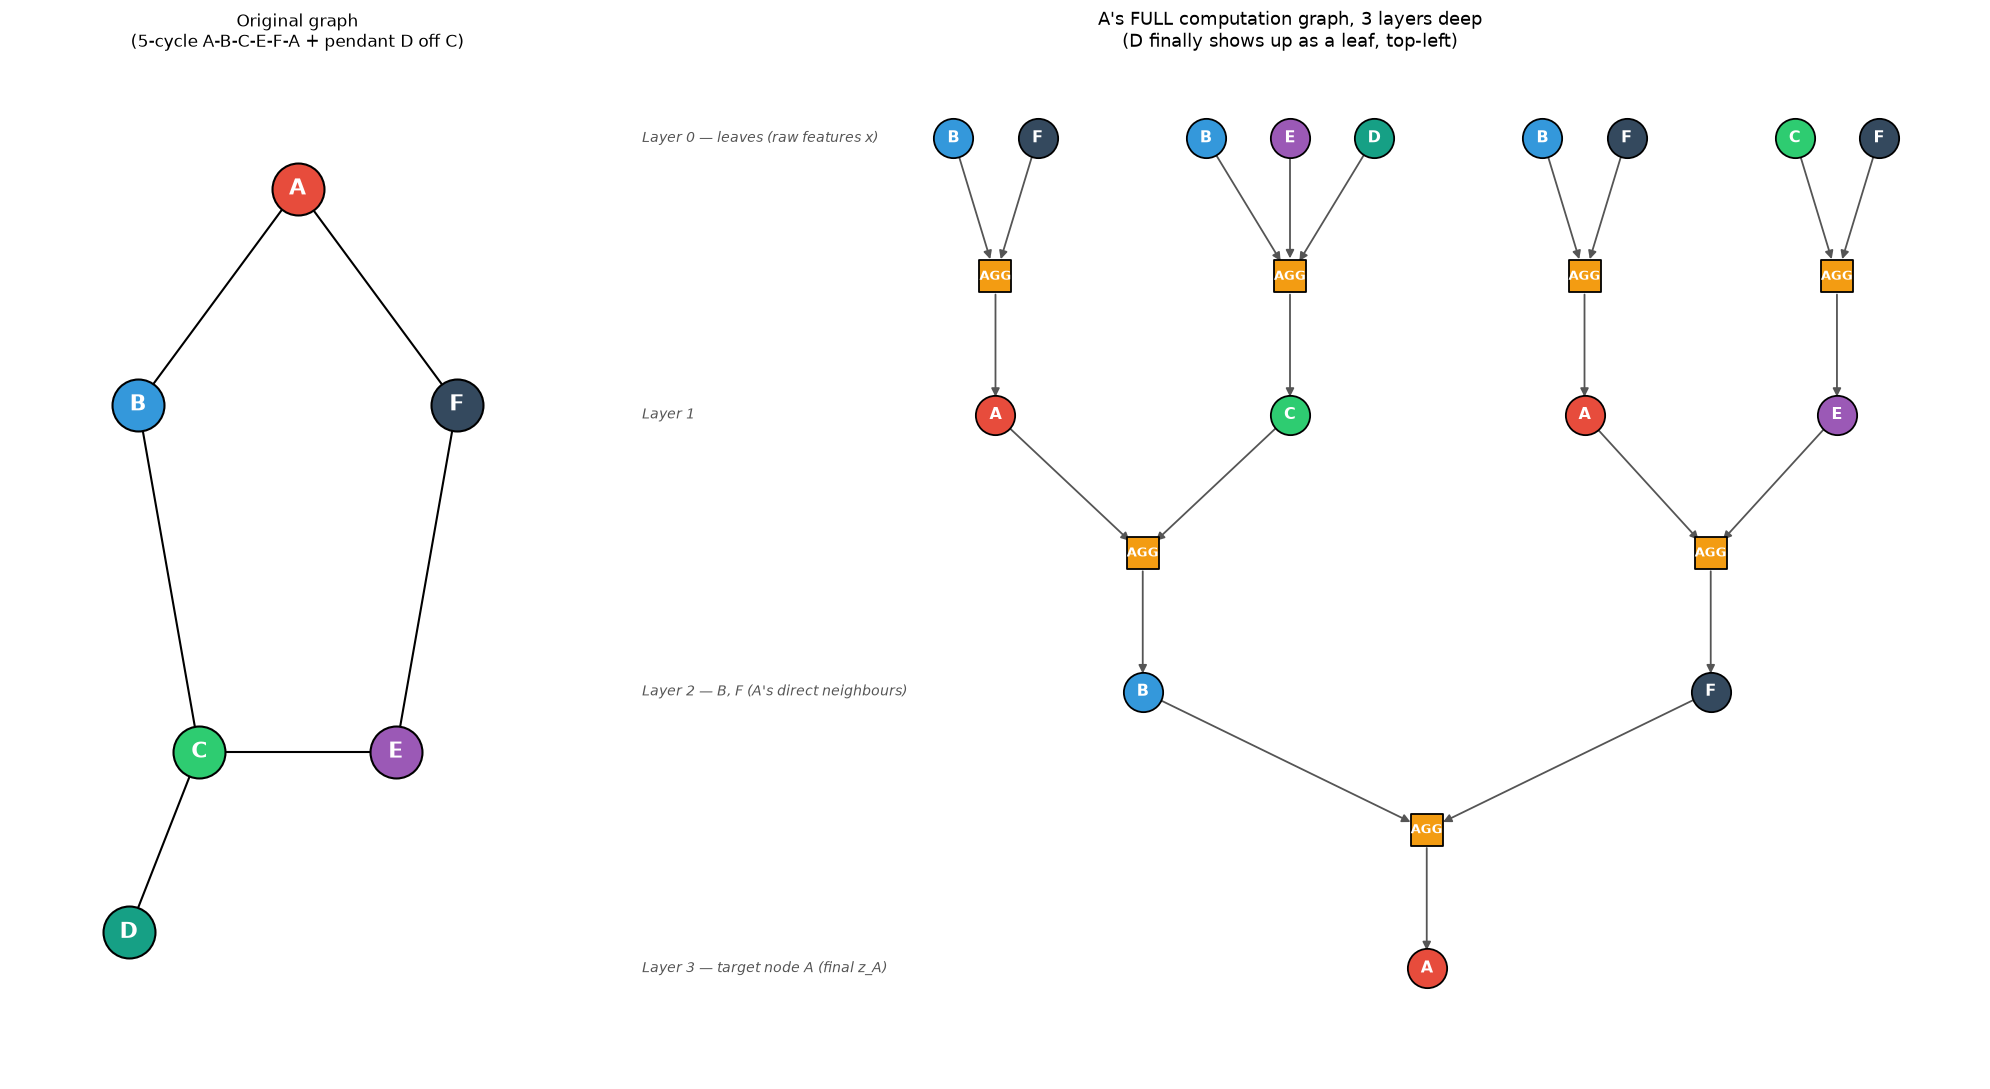

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 11), gridspec_kw={'width_ratios': [1, 2.4]})

color = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71', 'D': '#16a085', 'E': '#9b59b6', 'F': '#34495e'}

# ---------------- Left: the original graph ----------------
ax = axes[0]
pos = {
    'A': (0, 1.4), 'B': (-1.33, 0.43), 'C': (-0.82, -1.13),
    'E': (0.82, -1.13), 'F': (1.33, 0.43), 'D': (-1.41, -1.94),
}
edges = [('A', 'B'), ('B', 'C'), ('C', 'E'), ('E', 'F'), ('F', 'A'), ('C', 'D')]

for u, v in edges:
    x1, y1 = pos[u]; x2, y2 = pos[v]
    ax.plot([x1, x2], [y1, y2], 'k-', lw=1.5, zorder=1)

for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1400, color=color[node], zorder=2, edgecolors='black', linewidths=1.5)
    ax.text(x, y, node, ha='center', va='center', fontsize=16, fontweight='bold', color='white', zorder=3)

ax.set_title("Original graph\n(5-cycle A-B-C-E-F-A + pendant D off C)", fontsize=12)
ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.6, 2.0)
ax.axis('off')

# ---------------- Right: A's FULL 3-layer computation graph ----------------
ax = axes[1]

# key: (x, y, label, shape)  shape: 'o' node embedding, 's' AGG box
nodes = {
    # Layer 0 leaves (raw features)
    'L1_B': (-8, 5, 'B', 'o'), 'L1_F': (-7, 5, 'F', 'o'),
    'L2_B': (-5, 5, 'B', 'o'), 'L2_E': (-4, 5, 'E', 'o'), 'L2_D': (-3, 5, 'D', 'o'),
    'L3_B': (-1, 5, 'B', 'o'), 'L3_F': (0, 5, 'F', 'o'),
    'L4_C': (2, 5, 'C', 'o'), 'L4_F': (3, 5, 'F', 'o'),
    # AGG for layer 0 -> 1
    'AGG_AviaB': (-7.5, 4, 'AGG', 's'), 'AGG_CviaB': (-4, 4, 'AGG', 's'),
    'AGG_AviaF': (-0.5, 4, 'AGG', 's'), 'AGG_EviaF': (2.5, 4, 'AGG', 's'),
    # Layer 1 embeddings
    'AviaB': (-7.5, 3, 'A', 'o'), 'CviaB': (-4, 3, 'C', 'o'),
    'AviaF': (-0.5, 3, 'A', 'o'), 'EviaF': (2.5, 3, 'E', 'o'),
    # AGG for layer 1 -> 2
    'AGG_B': (-5.75, 2, 'AGG', 's'), 'AGG_F': (1.0, 2, 'AGG', 's'),
    # Layer 2 embeddings
    'B': (-5.75, 1, 'B', 'o'), 'F': (1.0, 1, 'F', 'o'),
    # AGG for layer 2 -> 3
    'AGG_A': (-2.375, 0, 'AGG', 's'),
    # Layer 3 = root
    'A': (-2.375, -1, 'A', 'o'),
}

edges_down = [
    ('L1_B', 'AGG_AviaB'), ('L1_F', 'AGG_AviaB'), ('AGG_AviaB', 'AviaB'),
    ('L2_B', 'AGG_CviaB'), ('L2_E', 'AGG_CviaB'), ('L2_D', 'AGG_CviaB'), ('AGG_CviaB', 'CviaB'),
    ('L3_B', 'AGG_AviaF'), ('L3_F', 'AGG_AviaF'), ('AGG_AviaF', 'AviaF'),
    ('L4_C', 'AGG_EviaF'), ('L4_F', 'AGG_EviaF'), ('AGG_EviaF', 'EviaF'),
    ('AviaB', 'AGG_B'), ('CviaB', 'AGG_B'), ('AGG_B', 'B'),
    ('AviaF', 'AGG_F'), ('EviaF', 'AGG_F'), ('AGG_F', 'F'),
    ('B', 'AGG_A'), ('F', 'AGG_A'), ('AGG_A', 'A'),
]

for u, v in edges_down:
    x1, y1, *_ = nodes[u]; x2, y2, *_ = nodes[v]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.3,
                                 shrinkA=13, shrinkB=13, mutation_scale=12))

for key, (x, y, label, shape) in nodes.items():
    node_color = '#f39c12' if shape == 's' else color[label]
    size = 500 if shape == 's' else 800
    ax.scatter(x, y, s=size, color=node_color, marker=shape, zorder=3, edgecolors='black', linewidths=1.3)
    ax.text(x, y, label, ha='center', va='center',
             fontsize=9 if shape == 's' else 11.5, fontweight='bold', color='white', zorder=4)

for y, text in [(5, 'Layer 0 — leaves (raw features x)'),
                 (3, 'Layer 1'),
                 (1, "Layer 2 — B, F (A's direct neighbours)"),
                 (-1, 'Layer 3 — target node A (final z_A)')]:
    ax.text(-11.7, y, text, ha='left', va='center', fontsize=10, style='italic', color='#555')

ax.set_title("A's FULL computation graph, 3 layers deep\n(D finally shows up as a leaf, top-left)", fontsize=13)
ax.set_xlim(-12.2, 4.2); ax.set_ylim(-1.8, 5.6)
ax.axis('off')

plt.tight_layout()
plt.show()

## Layer-by-Layer, For the Full 3-Layer Graph

**Layer 1** — every node that will eventually feed A computes its own 1-hop embedding from raw features. Five such computations happen (note **A** and **C** each get computed twice — once via each path that needs them):

$$h_A^{(1)} = \sigma\big(W^{(1)}\text{AGG}(x_B, x_F) + B^{(1)} x_A\big) \quad \text{(needed via B's branch)}$$
$$h_C^{(1)} = \sigma\big(W^{(1)}\text{AGG}(x_B, x_E, x_D) + B^{(1)} x_C\big) \quad \leftarrow \textbf{D enters here}$$
$$h_A^{(1)} = \sigma\big(W^{(1)}\text{AGG}(x_B, x_F) + B^{(1)} x_A\big) \quad \text{(needed via F's branch — same formula, recomputed)}$$
$$h_E^{(1)} = \sigma\big(W^{(1)}\text{AGG}(x_C, x_F) + B^{(1)} x_E\big)$$

This is the layer where **D first enters the picture** — inside $h_C^{(1)}$, because C's neighbours are B, E, **and D**.

**Layer 2** — B and F fold in their neighbours' layer-1 embeddings. But notice the final formula (below) also needs $h_A^{(2)}$ — A's *own* embedding after 2 rounds — as its self-term. That's not free either, so it gets computed here too, alongside B and F, using **A's own neighbours' layer-1 embeddings**:

$$h_B^{(2)} = \sigma\big(W^{(2)}\text{AGG}(h_A^{(1)}, h_C^{(1)}) + B^{(2)} h_B^{(1)}\big) \quad \leftarrow \textbf{D's trace, now inside } h_C^{(1)}\textbf{, reaches B}$$
$$h_F^{(2)} = \sigma\big(W^{(2)}\text{AGG}(h_A^{(1)}, h_E^{(1)}) + B^{(2)} h_F^{(1)}\big)$$
$$h_A^{(2)} = \sigma\big(W^{(2)}\text{AGG}(h_B^{(1)}, h_F^{(1)}) + B^{(2)} h_A^{(1)}\big) \quad \leftarrow \textbf{the self-term z\_A will need next}$$

This is exactly the same situation as the earlier 4-node cycle: A's self-term for its *final* update is never a free lookup once you're past layer 0 — it's the output of A's own AGG+UPDATE, run in parallel with B's and F's, using A's neighbours (B, F) one layer shallower.

**Layer 3 (final)** — A folds in B and F's layer-2 embeddings, plus its own $h_A^{(2)}$ from above:

$$z_A = h_A^{(3)} = \sigma\big(W^{(3)}\text{AGG}(h_B^{(2)}, h_F^{(2)}) + B^{(3)} h_A^{(2)}\big)$$

By the time we reach $z_A$, D's raw feature has travelled: $x_D \to h_C^{(1)} \to h_B^{(2)} \to z_A$ — three AGG steps, exactly matching its 3-hop distance from A. Meanwhile $h_A^{(2)}$ carries a 2-hop trace of A's *own* neighbourhood (B, F, and whatever they'd already picked up at layer 1) back into the final answer — the same "hearing your own echo" effect from the self-term discussion earlier, just one layer deeper here.

**What the full diagram makes obvious that the 2-layer version couldn't:** every node in the graph (A, B, C, D, E, F) appears *somewhere* in this computation now — D included, as a leaf under C's branch. A 2-layer model would have been structurally blind to D no matter how it was trained; a 3-layer model can see it, just diluted through two rounds of aggregation by the time it arrives.

## Eccentricity: Why Different Nodes Need Different Depths

**Eccentricity of a node = the distance to whichever other node is *farthest* from it.** Compute the hop-distance from that node to everyone else, keep the largest one.

On this graph:

| Node | Farthest node(s) | Eccentricity |
|---|---|---|
| A | D | 3 |
| B | F, E, D (tied) | 2 |
| C | A, F (tied) | 2 |
| D | A, F (tied) | 3 |
| E | B, D (tied) | 2 |
| F | D | 3 |

A, D, and F sit at the "edges" of the graph (eccentricity 3); B, C, and E are more central (eccentricity 2). The **diameter** of the graph is just the largest eccentricity overall — here, 3.

**A hard upper bound worth knowing:** for *any* connected graph with $V$ nodes, no shortest path can ever exceed $V - 1$ hops — a shortest path never revisits a node, so the longest possible one touches all $V$ nodes once each ($V-1$ edges). That worst case only happens for a plain chain graph with no shortcuts; any cycle or extra edge can only shrink distances, never grow them. Our graph has $V=6$, so the absolute worst case would be 5 — but the actual diameter is 3, because the 5-cycle gives everyone alternate routes. This is also *why* real-world graphs (social networks, citation graphs) stay shallow despite having millions of nodes — being well-connected (not chain-like) keeps eccentricities small regardless of size, which is the real reason 2–3 GNN layers is usually enough in practice.

---

## What If We Wanted K = 4 Layers?

A's eccentricity is 3, so 3 layers was already enough to reach every node. Let's push to **4 layers anyway** and see what happens — this makes the "going past your eccentricity buys nothing new" idea concrete.

**Layer 1** (all 6 nodes need their own 1-hop update):

$$h_A^{(1)} = \sigma(W^{(1)}\text{AGG}(x_B, x_F) + B^{(1)} x_A)$$
$$h_B^{(1)} = \sigma(W^{(1)}\text{AGG}(x_A, x_C) + B^{(1)} x_B)$$
$$h_C^{(1)} = \sigma(W^{(1)}\text{AGG}(x_B, x_E, x_D) + B^{(1)} x_C)$$
$$h_D^{(1)} = \sigma(W^{(1)}\text{AGG}(x_C) + B^{(1)} x_D) \quad \text{(D has just 1 neighbour)}$$
$$h_E^{(1)} = \sigma(W^{(1)}\text{AGG}(x_C, x_F) + B^{(1)} x_E)$$
$$h_F^{(1)} = \sigma(W^{(1)}\text{AGG}(x_A, x_E) + B^{(1)} x_F)$$

**Layer 2** (5 needed — D's own layer-2 isn't required, its trace already rode into $h_C^{(1)}$):

$$h_A^{(2)} = \sigma(W^{(2)}\text{AGG}(h_B^{(1)}, h_F^{(1)}) + B^{(2)} h_A^{(1)})$$
$$h_B^{(2)} = \sigma(W^{(2)}\text{AGG}(h_A^{(1)}, h_C^{(1)}) + B^{(2)} h_B^{(1)})$$
$$h_C^{(2)} = \sigma(W^{(2)}\text{AGG}(h_B^{(1)}, h_E^{(1)}, h_D^{(1)}) + B^{(2)} h_C^{(1)})$$
$$h_E^{(2)} = \sigma(W^{(2)}\text{AGG}(h_C^{(1)}, h_F^{(1)}) + B^{(2)} h_E^{(1)})$$
$$h_F^{(2)} = \sigma(W^{(2)}\text{AGG}(h_A^{(1)}, h_E^{(1)}) + B^{(2)} h_F^{(1)})$$

**Layer 3** (only 3 needed — A, B, F, the ones that directly feed A's next round):

$$h_A^{(3)} = \sigma(W^{(3)}\text{AGG}(h_B^{(2)}, h_F^{(2)}) + B^{(3)} h_A^{(2)})$$
$$h_B^{(3)} = \sigma(W^{(3)}\text{AGG}(h_A^{(2)}, h_C^{(2)}) + B^{(3)} h_B^{(2)})$$
$$h_F^{(3)} = \sigma(W^{(3)}\text{AGG}(h_A^{(2)}, h_E^{(2)}) + B^{(3)} h_F^{(2)})$$

**Layer 4 (final)**:

$$z_A = h_A^{(4)} = \sigma(W^{(4)}\text{AGG}(h_B^{(3)}, h_F^{(3)}) + B^{(4)} h_A^{(3)})$$

**The catch:** $x_D$ already reached $z_A$ back at **Layer 3** ($x_D \to h_C^{(1)} \to h_B^{(2)} \to h_A^{(3)}$). Going to Layer 4 doesn't pull in any node that wasn't already there — the *set* of raw features influencing $z_A$ is identical at Layer 3 and Layer 4. Only the numbers change, getting further smoothed. Layer 4 here is pure re-mixing, not new coverage.

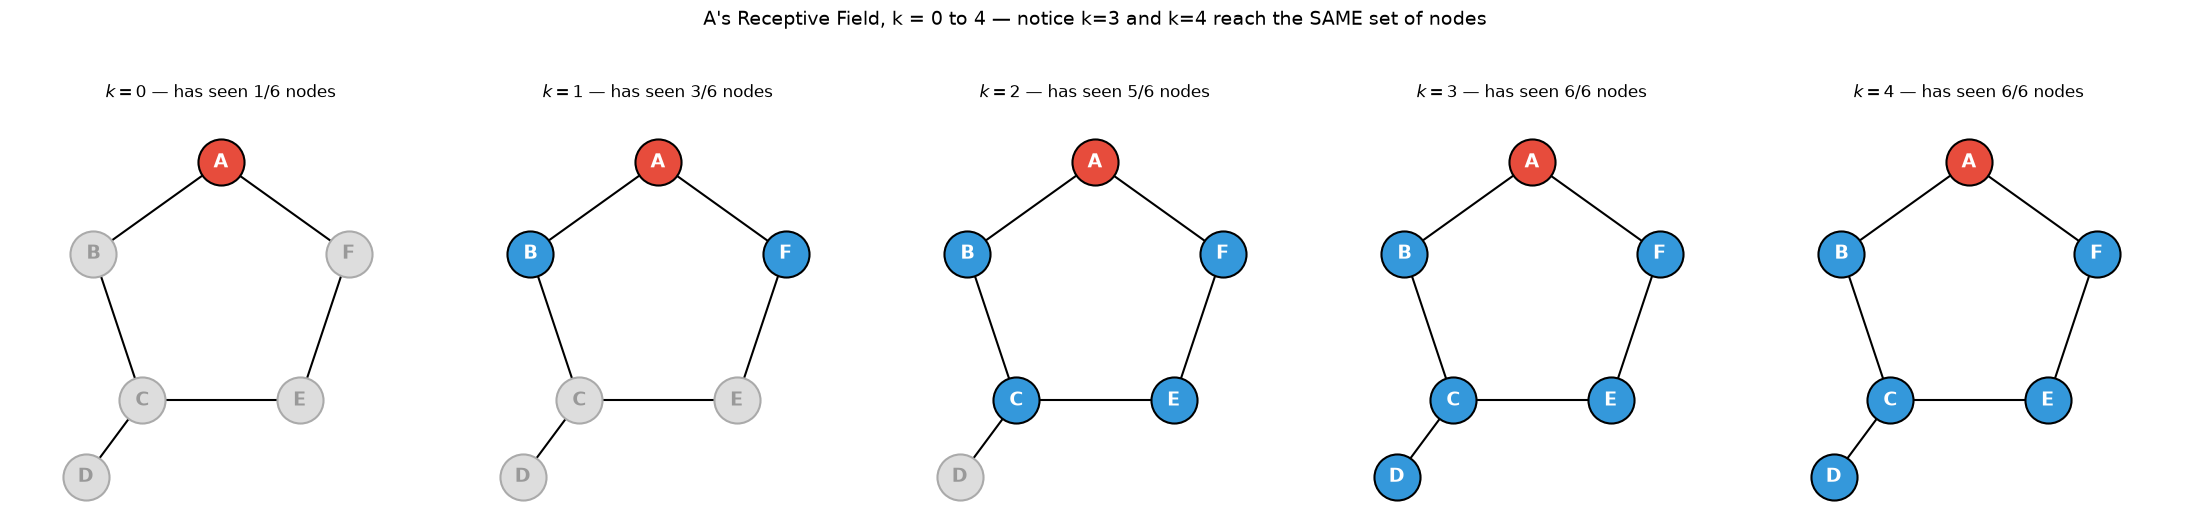

In [11]:
import matplotlib.pyplot as plt

pos = {
    'A': (0, 1.4), 'B': (-1.33, 0.43), 'C': (-0.82, -1.13),
    'E': (0.82, -1.13), 'F': (1.33, 0.43), 'D': (-1.41, -1.94),
}
edges = [('A', 'B'), ('B', 'C'), ('C', 'E'), ('E', 'F'), ('F', 'A'), ('C', 'D')]

# true hop-distance of every node from A
hop_distance = {'A': 0, 'B': 1, 'F': 1, 'C': 2, 'E': 2, 'D': 3}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for k, ax in zip([0, 1, 2, 3, 4], axes):
    for u, v in edges:
        x1, y1 = pos[u]; x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], 'k-', lw=1.5, zorder=1)

    for node, (x, y) in pos.items():
        reached = hop_distance[node] <= k
        color = '#e74c3c' if node == 'A' else ('#3498db' if reached else '#dddddd')
        ax.scatter(x, y, s=1100, color=color, zorder=2,
                   edgecolors='black' if reached else '#aaaaaa', linewidths=1.5)
        ax.text(x, y, node, ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if reached else '#999999', zorder=3)

    n_seen = sum(1 for n in hop_distance if hop_distance[n] <= k)
    ax.set_title(f"$k={k}$ — has seen {n_seen}/6 nodes", fontsize=12)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.4, 2.0)
    ax.axis('off')

plt.suptitle("A's Receptive Field, k = 0 to 4 — notice k=3 and k=4 reach the SAME set of nodes", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## Real-World Check: Eccentricity on the Cora Citation Graph

We've been computing eccentricity by hand on tiny 4–6 node graphs. Let's do it for real, on the actual **Cora** citation graph — the same one referenced earlier for its homophily ratio ($h \approx 0.81$). Cora has 2,708 papers and 5,429 citation links; we'll download the original dataset and treat citations as undirected edges (the standard choice for message passing — "who cites whom" matters less here than "these two papers are topically linked").

In [12]:
import urllib.request, tarfile, io
import networkx as nx
from collections import Counter

# download the real Cora dataset and parse cora.cites, entirely in memory
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
raw = urllib.request.urlopen(url, timeout=20).read()

G = nx.Graph()
with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tar:
    cites_file = tar.extractfile("cora/cora.cites")
    for line in cites_file:
        cited, citing = line.decode().split()
        G.add_edge(cited, citing)   # undirected: citation link = topical connection

print(f"Papers (nodes): {G.number_of_nodes()}")
print(f"Citation edges: {G.number_of_edges()}")

# Cora (undirected) is NOT fully connected -- eccentricity needs a connected graph,
# so we restrict to the largest connected component (standard practice)
components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"Connected components: {len(components)}")
print(f"Largest component: {len(components[0])} of {G.number_of_nodes()} papers")

giant = G.subgraph(components[0])
ecc = nx.eccentricity(giant)

diameter = max(ecc.values())
radius = min(ecc.values())
avg_ecc = sum(ecc.values()) / len(ecc)

print(f"\nDiameter (max eccentricity): {diameter}")
print(f"Radius (min eccentricity):   {radius}")
print(f"Average eccentricity:        {avg_ecc:.2f}")

print("\nEccentricity distribution:")
for k, count in sorted(Counter(ecc.values()).items()):
    print(f"  ecc={k:>2}: {count:>4} papers")

Papers (nodes): 2708
Citation edges: 5278
Connected components: 78
Largest component: 2485 of 2708 papers

Diameter (max eccentricity): 19
Radius (min eccentricity):   10
Average eccentricity:        13.45

Eccentricity distribution:
  ecc=10:    1 papers
  ecc=11:   85 papers
  ecc=12:  490 papers
  ecc=13:  786 papers
  ecc=14:  667 papers
  ecc=15:  313 papers
  ecc=16:   96 papers
  ecc=17:   32 papers
  ecc=18:   13 papers
  ecc=19:    2 papers


## Now Let's Prove Why K=2 Works: Homophily vs. Hop-Distance

We've been *asserting* that useful signal decays with distance while eccentricity stays large. Let's actually measure it: using Cora's real class labels (`cora.content`), compute what fraction of node-pairs share the same class, **as a function of hop-distance**. This directly extends the homophily ratio formula from earlier — that formula only ever measured 1-hop pairs (direct edges); here we measure it at every distance.

In [13]:
import urllib.request, tarfile, io
import networkx as nx
from collections import defaultdict, Counter

url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
raw = urllib.request.urlopen(url, timeout=20).read()

G = nx.Graph()
labels = {}
with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tar:
    cites_file = tar.extractfile("cora/cora.cites")
    for line in cites_file:
        cited, citing = line.decode().split()
        G.add_edge(cited, citing)

    content_file = tar.extractfile("cora/cora.content")
    for line in content_file:
        parts = line.decode().split()
        paper_id, class_label = parts[0], parts[-1]
        labels[paper_id] = class_label

class_counts = Counter(labels.values())
baseline = max(class_counts.values()) / len(labels)  # random-guess floor (largest class share)
print(f"Class distribution: {dict(class_counts)}")
print(f"Random-guess baseline (largest class share): {baseline:.3f}")

giant = G.subgraph(max(nx.connected_components(G), key=len))

same_1hop = sum(1 for u, v in giant.edges() if labels[u] == labels[v])
print(f"\n1-hop homophily ratio: {same_1hop/giant.number_of_edges():.3f}  (matches h ≈ 0.81 quoted earlier)")

# same-class rate at every hop distance -- this takes ~15-20s (all-pairs BFS on 2,485 nodes)
same_count, total_count = defaultdict(int), defaultdict(int)
for node, dist_dict in nx.all_pairs_shortest_path_length(giant):
    node_label = labels[node]
    for other, dist in dist_dict.items():
        if dist == 0:
            continue
        total_count[dist] += 1
        if labels[other] == node_label:
            same_count[dist] += 1

print(f"\n{'hop':>4} {'same-class %':>13} {'# pairs':>12}")
for d in sorted(total_count):
    pct = 100 * same_count[d] / total_count[d]
    print(f"{d:>4} {pct:>12.1f}% {total_count[d]//2:>12,}")

Class distribution: {'Neural_Networks': 818, 'Rule_Learning': 180, 'Reinforcement_Learning': 217, 'Probabilistic_Methods': 426, 'Theory': 351, 'Genetic_Algorithms': 418, 'Case_Based': 298}
Random-guess baseline (largest class share): 0.302

1-hop homophily ratio: 0.804  (matches h ≈ 0.81 quoted earlier)

 hop  same-class %      # pairs
   1         80.4%        5,069
   2         72.3%       43,051
   3         49.8%      123,537
   4         28.2%      331,582
   5         17.5%      593,520
   6         13.7%      694,729
   7         12.3%      559,174
   8         12.2%      346,515
   9         12.2%      189,033
  10         11.9%      102,424
  11         11.4%       54,501
  12         11.2%       26,686
  13         11.8%       11,264
  14         13.4%        3,807
  15         14.8%        1,101
  16         16.2%          296
  17         30.8%           65
  18         66.7%           15
  19        100.0%            1


**The actual numbers, run on real Cora:**

| Hop | Same-class % |
|---|---|
| 1 | 80.4% |
| 2 | 72.3% |
| 3 | 49.8% |
| 4 | 28.2% |
| 5 | 17.5% |
| 6+ | ~11–14% (below the ~30% random-guess baseline) |

**This is the concrete proof, not just an assertion:**

- **Hop 1–2**: same-class rate stays high (80% → 72%) — this is why going from $K{=}1$ to $K{=}2$ *helps*: real, still-reliable signal.
- **Hop 3**: drops to ~50% — signal is fading fast, roughly a coin flip whether the neighbour's class still matches.
- **Hop 4**: at 28%, it's already sitting *at* the random-guess baseline (30%, from the largest class's raw frequency). Beyond this point, a node this far away tells you essentially nothing about class — it's statistically indistinguishable from picking a random paper in the dataset.
- **Hop 5+**: same-class rate drops *below* baseline — pairs this far apart are, if anything, less likely to share a class than random chance would predict.

This is exactly why **K=2** (sometimes 3) is the empirical sweet spot for Cora: it's not an arbitrary number, and it's not tied to the graph's diameter (19) or average eccentricity (~13.45) at all. It's the point where the graph's real, measurable class-relevant signal runs out. Every layer past that isn't expanding useful coverage — it's mixing in what is, by this measurement, pure noise, while simultaneously smoothing embeddings together. Both effects push in the same bad direction, which is exactly why validation accuracy falls off a cliff past 3–4 layers in the original GCN experiments.

## Aggregation Functions — A Closer Look

The AGG step has one hard constraint: it must be **permutation invariant**. A node's neighbours are a *set*, not a sequence — there's no "1st neighbour" or "2nd neighbour" — so feeding them in any order must produce the same result. That rules out anything like plain concatenation, and is why sum/mean/max (not, say, an RNN over the raw neighbour order) are the default choices.

| Aggregator | Formula | Property |
|---|---|---|
| **Sum** | $\sum_{u \in \mathcal{N}(v)} h_u$ | most expressive (see below); grows with neighbour count / degree |
| **Mean** | $\frac{1}{\|\mathcal{N}(v)\|}\sum_{u \in \mathcal{N}(v)} h_u$ | degree-normalized; used in GCN |
| **Max** | elementwise $\max_{u \in \mathcal{N}(v)} h_u$ | keeps the strongest signal per dimension, ignores the rest; used in GraphSAGE-pool |
| **Attention-weighted** | $\sum_{u \in \mathcal{N}(v)} \alpha_{vu}\, h_u$ | learns *which* neighbours matter — weights $\alpha_{vu}$ come from a trainable attention score; used in GAT |
| **LSTM** | LSTM over a random permutation of $\{h_u\}$ | technically not permutation-invariant, GraphSAGE makes it work anyway by randomizing neighbour order during training |

Let's see these actually differ on numbers, not just formulas.

In [ ]:
import numpy as np

# reuse the exact Rock/Jazz preference vectors from the LBP example
x_A = np.array([0.9, 0.1])   # A: strong Rock fan
x_C = np.array([0.1, 0.9])   # C: strong Jazz fan
x_B = np.array([0.5, 0.5])   # B's own prior (undecided)

neighbours = np.stack([x_A, x_C])   # B's neighbours in the cycle graph: A and C

agg_sum  = neighbours.sum(axis=0)
agg_mean = neighbours.mean(axis=0)
agg_max  = neighbours.max(axis=0)
agg_min  = neighbours.min(axis=0)

print(f"{'aggregator':<10} {'Rock':>6} {'Jazz':>6}   sums to 1?")
for name, vec in [('sum', agg_sum), ('mean', agg_mean), ('max', agg_max), ('min', agg_min)]:
    print(f"{name:<10} {vec[0]:>6.2f} {vec[1]:>6.2f}   {'yes' if np.isclose(vec.sum(), 1) else 'no'}")

## Notes

## Experiments